# SignalGateway API Validation Notebook

这个 notebook 用来验证本地 `SignalGateway` FastAPI 服务与模拟盘结果。

覆盖内容：
- API 连通性检查
- `status / config / runtime / performance / analytics` 数据加载
- 模拟盘收益、回撤、换手、交易活跃度、持仓暴露图表
- 当前持仓、策略配置、OMS 状态、原始返回结构检查
- API 控制按钮：`start / stop / run-once / refresh`

默认服务地址：`http://127.0.0.1:8000`

In [1]:
from __future__ import annotations

from datetime import datetime
from typing import Any

import json

import httpx
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, Markdown, display

try:
    import ipywidgets as widgets
except ImportError:
    widgets = None

BASE_URL = "http://127.0.0.1:8000"
TIMEOUT = 30.0

plt.style.use("ggplot")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 300)
print(f"Base URL: {BASE_URL}")
print(f"Loaded at: {datetime.now().isoformat(timespec='seconds')}")

Base URL: http://127.0.0.1:8000
Loaded at: 2026-04-24T17:57:15


In [2]:
def api_get(path: str, *, params: dict[str, Any] | None = None) -> dict[str, Any]:
    url = f"{BASE_URL}{path}"
    with httpx.Client(timeout=TIMEOUT) as client:
        response = client.get(url, params=params)
        response.raise_for_status()
        return response.json()


def api_post(path: str, payload: dict[str, Any] | None = None) -> dict[str, Any]:
    url = f"{BASE_URL}{path}"
    with httpx.Client(timeout=TIMEOUT) as client:
        response = client.post(url, json=payload)
        response.raise_for_status()
        return response.json() if response.content else {"status_code": response.status_code}


def fetch_endpoint(path: str, *, method: str = "GET", payload: dict[str, Any] | None = None) -> dict[str, Any]:
    started = datetime.now()
    try:
        data = api_get(path) if method == "GET" else api_post(path, payload)
        return {
            "ok": True,
            "path": path,
            "method": method,
            "latency_ms": round((datetime.now() - started).total_seconds() * 1000, 1),
            "data": data,
            "error": None,
        }
    except Exception as exc:
        return {
            "ok": False,
            "path": path,
            "method": method,
            "latency_ms": round((datetime.now() - started).total_seconds() * 1000, 1),
            "data": None,
            "error": str(exc),
        }


def frame_from_records(records: Any) -> pd.DataFrame:
    if records is None:
        return pd.DataFrame()
    if isinstance(records, pd.DataFrame):
        return records.copy()
    if isinstance(records, list):
        return pd.json_normalize(records) if records else pd.DataFrame()
    if isinstance(records, dict):
        return pd.json_normalize(records)
    return pd.DataFrame({"value": [records]})


def maybe_to_datetime(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    out = df.copy()
    for column in columns:
        if column in out.columns:
            out[column] = pd.to_datetime(out[column], errors="coerce")
    return out


def flatten_dict(data: dict[str, Any], prefix: str = "") -> dict[str, Any]:
    result: dict[str, Any] = {}
    for key, value in data.items():
        full_key = f"{prefix}.{key}" if prefix else key
        if isinstance(value, dict):
            result.update(flatten_dict(value, full_key))
        else:
            result[full_key] = value
    return result


def kv_frame(data: dict[str, Any]) -> pd.DataFrame:
    if not data:
        return pd.DataFrame(columns=["key", "value"])
    flat = flatten_dict(data)
    return pd.DataFrame({"key": list(flat.keys()), "value": list(flat.values())})


def card_html(title: str, value: Any, subtitle: str = "") -> str:
    pretty = "-" if value is None or value == "" else value
    return f"""
    <div style='padding:14px 16px;border-radius:12px;background:#f7f9fb;border:1px solid #d9e2ec;min-width:180px;'>
      <div style='font-size:12px;color:#486581;text-transform:uppercase;letter-spacing:.06em;'>{title}</div>
      <div style='font-size:24px;font-weight:700;color:#102a43;margin-top:6px;'>{pretty}</div>
      <div style='font-size:12px;color:#7b8794;margin-top:6px;'>{subtitle}</div>
    </div>
    """


def show_cards(cards: list[str]) -> None:
    display(HTML("<div style='display:flex;flex-wrap:wrap;gap:12px;'>" + "".join(cards) + "</div>"))


def display_endpoint_checks(df: pd.DataFrame) -> None:
    if df.empty:
        display(df)
        return
    try:
        styled = df.style.hide(axis="index").apply(
            lambda row: ["background-color: #e6ffed" if bool(row["ok"]) else "background-color: #ffe3e3"] * len(row),
            axis=1,
        )
        display(styled)
    except Exception:
        display(df)


def interactive_table(df: pd.DataFrame, name: str = "DataFrame"):
    df = df.copy()
    if df.empty:
        display(Markdown(f"**{name}:** no rows"))
        return None
    if widgets is None:
        display(Markdown(f"### {name}"))
        display(df)
        return None

    text = widgets.Text(value="", description="Filter", placeholder="keyword")
    sort_col = widgets.Dropdown(options=[""] + list(df.columns), value="", description="Sort")
    ascending = widgets.Checkbox(value=False, description="Ascending")
    limit = widgets.IntSlider(value=min(20, len(df)), min=1, max=max(1, len(df)), step=1, description="Rows")
    output = widgets.Output()

    def render(*_):
        filtered = df.copy()
        query = text.value.strip().lower()
        if query:
            mask = filtered.astype(str).apply(lambda col: col.str.lower().str.contains(query, na=False))
            filtered = filtered[mask.any(axis=1)]
        if sort_col.value:
            filtered = filtered.sort_values(sort_col.value, ascending=ascending.value, na_position="last")
        filtered = filtered.head(limit.value)
        with output:
            output.clear_output()
            display(filtered)

    for widget in [text, sort_col, ascending, limit]:
        widget.observe(render, names="value")
    render()
    display(Markdown(f"### {name}"))
    display(widgets.VBox([widgets.HBox([text, sort_col, ascending, limit]), output]))
    return output


def safe_json_preview(data: Any, title: str, limit: int = 4000) -> None:
    text = json.dumps(data, ensure_ascii=False, indent=2, default=str)
    display(Markdown(f"### {title}"))
    display(HTML(f"<pre style='max-height:420px;overflow:auto;background:#f7f9fb;padding:12px;border:1px solid #d9e2ec;border-radius:8px'>{text[:limit]}</pre>"))


def fetch_bundle() -> dict[str, Any]:
    endpoints = {
        "health": "/health",
        "status": "/service/status",
        "config": "/service/config",
        "runtime": "/service/runtime",
        "performance": "/service/performance",
        "analytics": "/service/analytics",
    }
    results = {name: fetch_endpoint(path) for name, path in endpoints.items()}
    return {
        "results": results,
        "data": {name: item["data"] for name, item in results.items() if item["ok"]},
        "errors": {name: item["error"] for name, item in results.items() if not item["ok"]},
    }

In [3]:
bundle = fetch_bundle()
endpoint_df = pd.DataFrame([
    {
        "name": name,
        "method": item["method"],
        "path": item["path"],
        "ok": item["ok"],
        "latency_ms": item["latency_ms"],
        "error": item["error"],
        "keys": ", ".join(list(item["data"].keys())[:8]) if isinstance(item["data"], dict) else None,
    }
    for name, item in bundle["results"].items()
])
display_endpoint_checks(endpoint_df)

if bundle["errors"]:
    display(Markdown("### Endpoint Errors"))
    display(pd.DataFrame({"endpoint": list(bundle["errors"].keys()), "error": list(bundle["errors"].values())}))

name,method,path,ok,latency_ms,error,keys
health,GET,/health,True,961.100000,None,status
status,GET,/service/status,True,52.000000,None,"session_id, mode, running, scheduler, last_error, last_result"
config,GET,/service/config,True,50.300000,None,"session_id, service, selection_provider, strategies"
runtime,GET,/service/runtime,True,47.800000,None,"session_id, generated_at, positions, oms_state"
performance,GET,/service/performance,True,715.000000,None,"session_id, generated_at, summary, holding_returns, turnover, equity_curve, trade_activity, position_exposure"
analytics,GET,/service/analytics,True,342.400000,None,"session_id, generated_at, status, runtime, performance, config"


In [4]:
data = bundle["data"]

health = data.get("health", {})
status = data.get("status", {})
config = data.get("config", {})
runtime = data.get("runtime", {})
performance = data.get("performance", {})
analytics = data.get("analytics", {})

analytics_runtime = analytics.get("runtime", {})
analytics_performance = analytics.get("performance", {})
analytics_config = analytics.get("config", {})
runtime_positions = runtime.get("positions", analytics_runtime.get("positions", {}))
oms_state = runtime.get("oms_state", analytics_runtime.get("oms_state", {}))

equity_df = maybe_to_datetime(frame_from_records(performance.get("equity_curve", analytics_performance.get("equity_curve", []))), ["trade_date"])
trade_activity_df = maybe_to_datetime(frame_from_records(performance.get("trade_activity", analytics_performance.get("trade_activity", []))), ["trade_date"])
turnover_df = maybe_to_datetime(frame_from_records(performance.get("turnover", analytics_performance.get("turnover", []))), ["trade_date"])
holding_returns_df = maybe_to_datetime(frame_from_records(performance.get("holding_returns", analytics_performance.get("holding_returns", []))), ["trade_date", "latest_date"])

positions_df = frame_from_records(analytics_runtime.get("positions", {}).get("holds", runtime_positions.get("holds", [])))
pending_orders_df = frame_from_records(analytics_runtime.get("positions", {}).get("pending_orders", runtime_positions.get("pending_orders", [])))
strategy_specs_df = frame_from_records(analytics_config.get("strategies", config.get("strategies", [])))
top_positions_df = frame_from_records(performance.get("position_exposure", {}).get("top_positions", []))
selection_provider_df = kv_frame(analytics_config.get("selection_provider", config.get("selection_provider", {})))
service_config_df = kv_frame(analytics_config.get("service", config.get("service", {})))
status_df = kv_frame(status)
oms_state_df = kv_frame(oms_state if isinstance(oms_state, dict) else {})

summary = performance.get("summary", analytics_performance.get("summary", {}))
latest_portfolio = performance.get("latest_portfolio", analytics_performance.get("latest_portfolio", {}))
position_exposure = performance.get("position_exposure", analytics_performance.get("position_exposure", {}))

win_rate = summary.get("win_rate")
win_rate_pct = round(win_rate * 100, 2) if isinstance(win_rate, (int, float)) else win_rate

show_cards([
    card_html("Health", health.get("status")),
    card_html("Session", status.get("session_id") or runtime.get("session_id") or analytics_runtime.get("session_id")),
    card_html("Mode", status.get("mode")),
    card_html("Scheduler Running", status.get("running")),
    card_html("Total Trades", summary.get("total_trades")),
    card_html("Win Rate", win_rate_pct, "%"),
    card_html("Portfolio Value", round(latest_portfolio.get("portfolio_value", 0), 2)),
    card_html("Cash Ratio", round(float(latest_portfolio.get("cash_ratio", 0) or 0) * 100, 2), "%"),
    card_html("Position Count", position_exposure.get("position_count")),
    card_html("Max Drawdown", round(float(summary.get("max_drawdown", 0) or 0) * 100, 2), "%"),
])

In [5]:
display(Markdown("## Core Snapshots"))
interactive_table(status_df, "Service Status")
interactive_table(service_config_df, "Service Config")
interactive_table(selection_provider_df, "Selection Provider Config")
interactive_table(strategy_specs_df, "Strategy Specs")

## Core Snapshots

### Service Status

### Service Config

### Selection Provider Config

### Strategy Specs

Output()

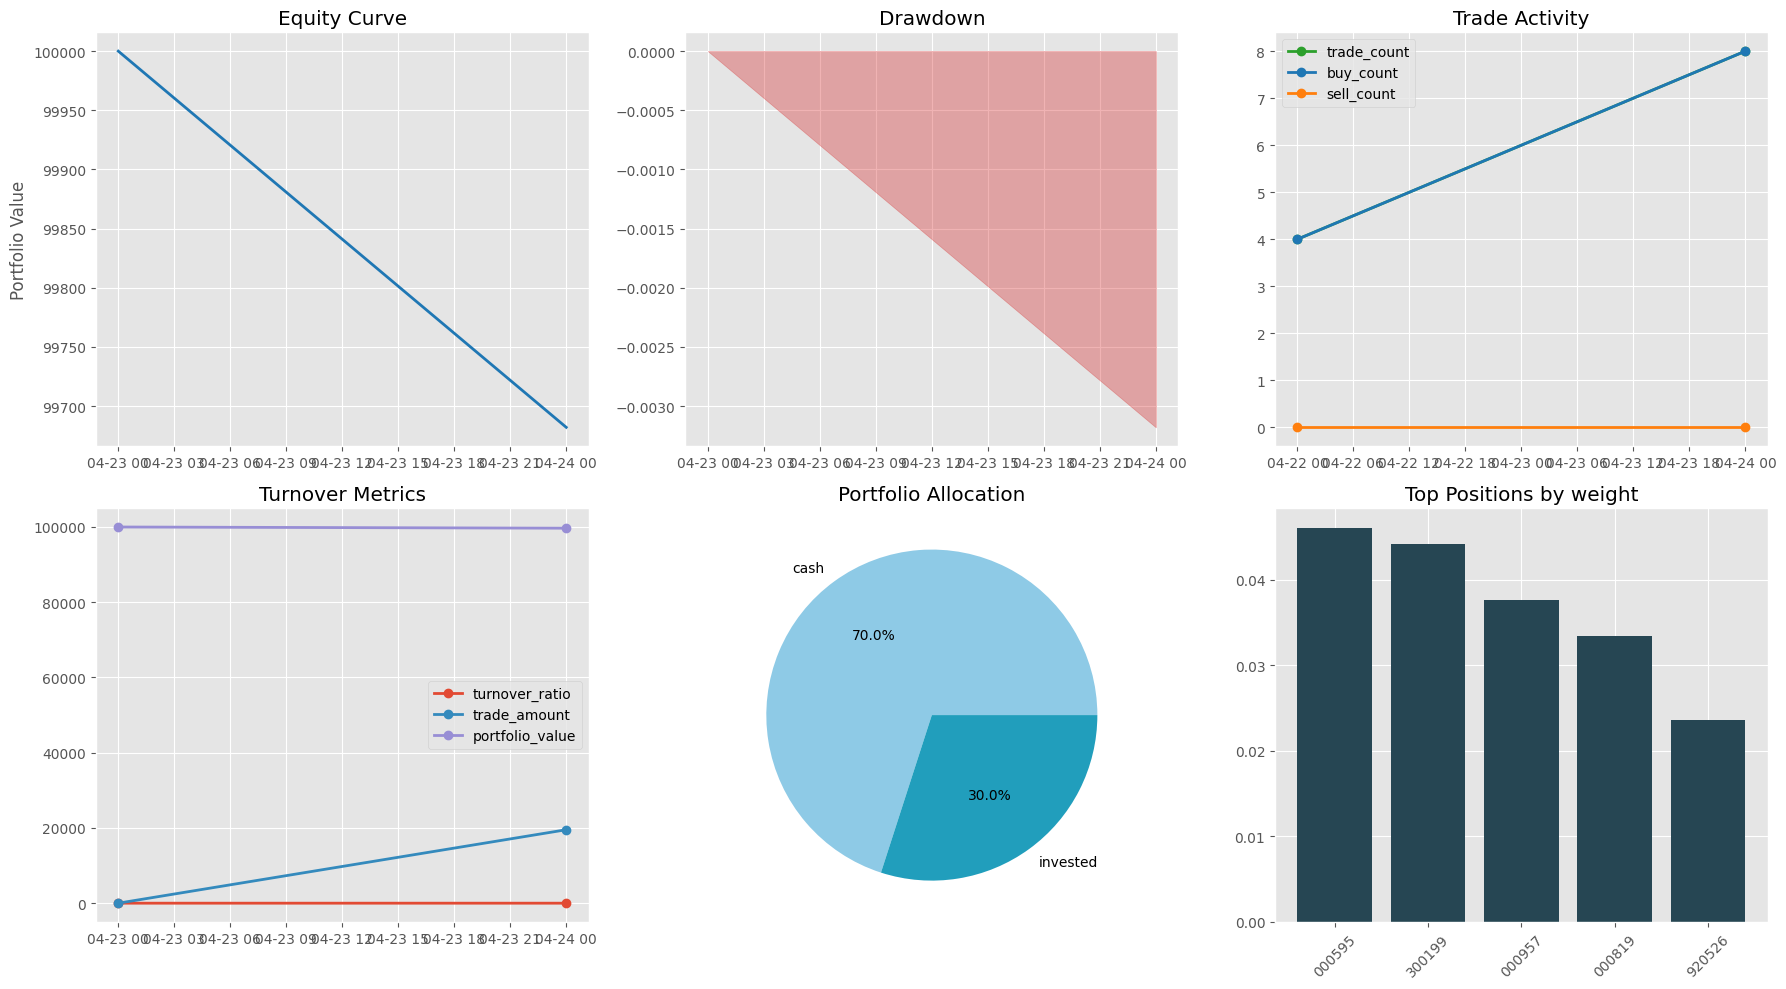

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

if not equity_df.empty and {"trade_date", "portfolio_value"}.issubset(equity_df.columns):
    axes[0].plot(equity_df["trade_date"], equity_df["portfolio_value"], color="#1f77b4", linewidth=2)
    axes[0].set_title("Equity Curve")
    axes[0].set_ylabel("Portfolio Value")
else:
    axes[0].text(0.5, 0.5, "No equity curve data", ha="center", va="center")
    axes[0].set_axis_off()

if not equity_df.empty and {"trade_date", "drawdown"}.issubset(equity_df.columns):
    axes[1].fill_between(equity_df["trade_date"], equity_df["drawdown"], color="#d62728", alpha=0.35)
    axes[1].set_title("Drawdown")
else:
    axes[1].text(0.5, 0.5, "No drawdown data", ha="center", va="center")
    axes[1].set_axis_off()

if not trade_activity_df.empty and "trade_date" in trade_activity_df.columns:
    for column, color in [("trade_count", "#2ca02c"), ("buy_count", "#1f77b4"), ("sell_count", "#ff7f0e")]:
        if column in trade_activity_df.columns:
            axes[2].plot(trade_activity_df["trade_date"], trade_activity_df[column], marker="o", linewidth=2, label=column, color=color)
    axes[2].set_title("Trade Activity")
    axes[2].legend()
else:
    axes[2].text(0.5, 0.5, "No trade activity data", ha="center", va="center")
    axes[2].set_axis_off()

if not turnover_df.empty and "trade_date" in turnover_df.columns:
    plotted = False
    for column in ["turnover_ratio", "trade_amount", "portfolio_value"]:
        if column in turnover_df.columns:
            axes[3].plot(turnover_df["trade_date"], turnover_df[column], marker="o", linewidth=2, label=column)
            plotted = True
    if plotted:
        axes[3].set_title("Turnover Metrics")
        axes[3].legend()
    else:
        axes[3].text(0.5, 0.5, "No expected turnover fields", ha="center", va="center")
        axes[3].set_axis_off()
else:
    axes[3].text(0.5, 0.5, "No turnover data", ha="center", va="center")
    axes[3].set_axis_off()

cash_ratio = float(latest_portfolio.get("cash_ratio", 0) or 0)
invested_ratio = float(latest_portfolio.get("invested_ratio", 0) or 0)
if cash_ratio > 0 or invested_ratio > 0:
    axes[4].pie([cash_ratio, invested_ratio], labels=["cash", "invested"], autopct="%1.1f%%", colors=["#8ecae6", "#219ebc"])
    axes[4].set_title("Portfolio Allocation")
else:
    axes[4].text(0.5, 0.5, "No portfolio allocation data", ha="center", va="center")
    axes[4].set_axis_off()

if not top_positions_df.empty:
    metric = "weight" if "weight" in top_positions_df.columns else ("market_value" if "market_value" in top_positions_df.columns else None)
    if metric:
        top_positions_plot = top_positions_df.sort_values(metric, ascending=False).head(8)
        axes[5].bar(top_positions_plot["symbol"], top_positions_plot[metric], color="#264653")
        axes[5].set_title(f"Top Positions by {metric}")
        axes[5].tick_params(axis="x", rotation=45)
    else:
        axes[5].text(0.5, 0.5, "Top position metric missing", ha="center", va="center")
        axes[5].set_axis_off()
else:
    axes[5].text(0.5, 0.5, "No top positions data", ha="center", va="center")
    axes[5].set_axis_off()

plt.tight_layout()
plt.show()

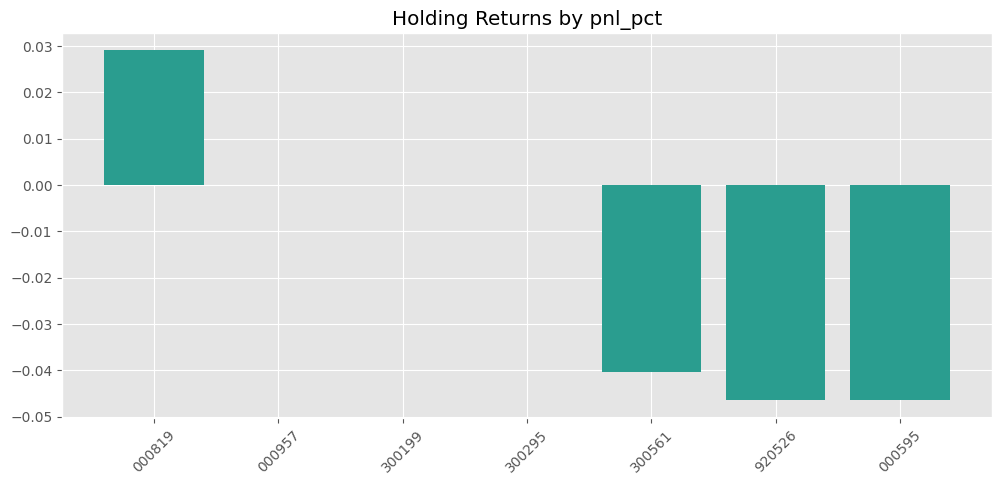

In [7]:
if not holding_returns_df.empty:
    metric = next((column for column in ["pnl_pct", "pnl", "market_value"] if column in holding_returns_df.columns), None)
    if metric:
        plot_df = holding_returns_df.sort_values(metric, ascending=False).head(12)
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.bar(plot_df["symbol"], plot_df[metric], color="#2a9d8f")
        ax.set_title(f"Holding Returns by {metric}")
        ax.tick_params(axis="x", rotation=45)
        plt.show()
    else:
        display(Markdown("Holding returns data exists but expected numeric fields were not found."))
else:
    display(Markdown("No holding returns data available."))

In [8]:
display(Markdown("## Data Tables"))
interactive_table(equity_df, "Equity Curve")
interactive_table(trade_activity_df, "Trade Activity")
interactive_table(turnover_df, "Turnover")
interactive_table(holding_returns_df, "Holding Returns")
interactive_table(positions_df, "Current Holds")
interactive_table(top_positions_df, "Top Position Exposure")
interactive_table(pending_orders_df, "Pending Orders")
interactive_table(oms_state_df, "OMS State")

## Data Tables

### Equity Curve

### Trade Activity

### Turnover

### Holding Returns

### Current Holds

### Top Position Exposure

**Pending Orders:** no rows

### OMS State

Output()

In [9]:
safe_json_preview(runtime, "Raw Runtime JSON")
safe_json_preview(performance, "Raw Performance JSON")
safe_json_preview(analytics, "Raw Analytics JSON")

### Raw Runtime JSON

### Raw Performance JSON

### Raw Analytics JSON

In [10]:
if widgets is None:
    display(Markdown("`ipywidgets` not installed, skipping API control panel."))
else:
    output = widgets.Output(layout=widgets.Layout(border="1px solid #d9e2ec", padding="8px"))
    refresh_btn = widgets.Button(description="Refresh", button_style="info")
    start_btn = widgets.Button(description="Start Scheduler", button_style="success")
    stop_btn = widgets.Button(description="Stop Scheduler", button_style="warning")
    run_once_btn = widgets.Button(description="Run Once", button_style="primary")
    health_btn = widgets.Button(description="Health", button_style="")

    def log_json(title: str, payload: dict[str, Any]):
        with output:
            print(f"\n[{datetime.now().isoformat(timespec='seconds')}] {title}")
            print(json.dumps(payload, ensure_ascii=False, indent=2, default=str))

    def on_refresh(_):
        log_json("GET /service/runtime", fetch_endpoint("/service/runtime")["data"] or fetch_endpoint("/service/runtime"))

    def on_start(_):
        log_json("POST /service/start", api_post("/service/start"))

    def on_stop(_):
        log_json("POST /service/stop", api_post("/service/stop"))

    def on_run_once(_):
        log_json("POST /service/run-once", api_post("/service/run-once"))

    def on_health(_):
        log_json("GET /health", api_get("/health"))

    refresh_btn.on_click(on_refresh)
    start_btn.on_click(on_start)
    stop_btn.on_click(on_stop)
    run_once_btn.on_click(on_run_once)
    health_btn.on_click(on_health)

    display(Markdown("## API Control Panel"))
    display(widgets.HBox([health_btn, refresh_btn, start_btn, stop_btn, run_once_btn]))
    display(output)

## API Control Panel

Output(layout=Layout(border_bottom='1px solid #d9e2ec', border_left='1px solid #d9e2ec', border_right='1px sol…

## 建议验证顺序

1. 先执行 helper 和 `fetch_bundle()` 单元格。
2. 看 Endpoint 检查表，确认关键接口都正常。
3. 看 summary cards 与 `Core Snapshots`，确认会话配置、运行状态和策略参数符合预期。
4. 看权益、回撤、换手、活跃度和持仓暴露图表，判断模拟盘表现是否合理。
5. 用交互表格检查当前持仓、OMS 状态和原始性能明细。
6. 如需推进数据，再用控制面板执行 `run-once` 或开启 scheduler，之后重新运行 `fetch_bundle()`。